# Proyecto: Predicción inteligente de gasto en clientes e-commerce

## Clase 1: Fundamentos del Aprendizaje de Máquina

### 1. Diferenciar problemas de clasificación y regresión.
En el aprendizaje de máquina supervisado, la diferencia fundamental radica en el tipo de resultado (variable objetivo) que el modelo debe predecir:

* **Regresión:** Se utiliza cuando el objetivo es predecir un valor numérico y continuo (un número real). Por ejemplo: estimar la temperatura de mañana, el precio de una propiedad o el monto en dólares que gastará un cliente.
* **Clasificación:** Se utiliza cuando el objetivo es asignar un dato a una categoría o etiqueta discreta. Por ejemplo: predecir si un correo electrónico es "Spam" o "No Spam", o si un cliente "Comprará" o "No Comprará" un producto.

### 2. Identificar las etapas del pipeline de un proyecto ML.

1. **Definición del Problema:** Comprender la necesidad del negocio y establecer el objetivo predictivo.
2. **Recolección de Datos:** Obtener los datos históricos relevantes.
3. **Análisis Exploratorio (EDA):** Visualizar y analizar las distribuciones y correlaciones entre variables.
4. **Preprocesamiento:** Limpiar los datos, tratar valores nulos, aplicar codificación y escalar las variables numéricas.
5. **División de Datos:** Separar el conjunto de datos en Entrenamiento (Train) y Prueba (Test).
6. **Entrenamiento de Modelos:** Seleccionar y entrenar los algoritmos adecuados.
7. **Evaluación:** Medir el desempeño del modelo utilizando métricas específicas (MAE, RMSE, R²).
8. **Optimización:** Mejorar el rendimiento mediante el ajuste de hiperparámetros.

### 3. Definir el problema como regresión supervisada.
Para responder a la solicitud del Departamento de Analítica Comercial, el enfoque técnico es el siguiente:

* **Enfoque de Aprendizaje:** Supervisado, ya que utilizaremos datos históricos donde ya conocemos el gasto de los clientes para entrenar al algoritmo.
* **Tipo de Tarea:** Regresión Supervisada. Nuestro objetivo es predecir el **monto de compra esperado**, el cual es un valor numérico continuo. Variables como la edad y el tiempo en la plataforma serán nuestras características predictoras (features).

In [9]:
# 1. Importación de librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-Learn para modelado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Entorno preparado para el proyecto de E-commerce")
print("-" * 40)

# 2. Creación del dataset sintético (500 clientes)
np.random.seed(42) # Semilla para reproducibilidad
n_clientes = 500

data = {
    'Edad': np.random.randint(18, 70, n_clientes),
    'Tiempo_en_App': np.random.uniform(10, 20, n_clientes),
    'Tiempo_en_Web': np.random.uniform(30, 45, n_clientes),
    'Anios_Membresia': np.random.uniform(0, 7, n_clientes),
}

# Variable objetivo (Target) con un poco de ruido
data['Gasto_Anual'] = (data['Anios_Membresia'] * 60) + (data['Tiempo_en_App'] * 12) + (data['Edad'] * 0.5) + np.random.normal(0, 10, n_clientes)

df = pd.DataFrame(data)

# 3. Definición del problema
print("--- Definición del Proyecto ---")
print("Tipo de Problema: Regresión Supervisada")
print("Variable Objetivo (Target): Gasto_Anual")
print("Variables Predictoras (Features): Edad, Tiempo_en_App, Tiempo_en_Web, Anios_Membresia")
print("\nPrimeras filas del dataset:")
print(df.head())

Entorno preparado para el proyecto de E-commerce
----------------------------------------
--- Definición del Proyecto ---
Tipo de Problema: Regresión Supervisada
Variable Objetivo (Target): Gasto_Anual
Variables Predictoras (Features): Edad, Tiempo_en_App, Tiempo_en_Web, Anios_Membresia

Primeras filas del dataset:
   Edad  Tiempo_en_App  Tiempo_en_Web  Anios_Membresia  Gasto_Anual
0    56      19.548653      38.060934         6.831057   677.006119
1    69      17.378969      43.797834         2.358271   406.193886
2    46      15.543541      35.195190         1.274825   279.576829
3    32      16.117207      35.204298         5.527890   550.358264
4    60      14.196001      41.062519         4.610954   477.579404


## Clase 2: Nivel de Ajuste y Validación Cruzada

### 1. Sobreajuste (Overfitting) vs. Subajuste (Underfitting)
Para que el modelo sea útil para el Departamento de Analítica, debe generalizar bien ante nuevos clientes.
* **Subajuste (Underfitting):** El modelo es demasiado simple y no captura los patrones (errores altos tanto en entrenamiento como en prueba).
* **Sobreajuste (Overfitting):** El modelo es demasiado complejo y memoriza el ruido de los datos (error muy bajo en entrenamiento, pero muy alto en prueba).
* **Buen Ajuste:** El modelo encuentra el equilibrio y tiene errores similares y bajos en ambos conjuntos.

### 2. Validación Cruzada (K-Folds)
En lugar de confiar en una sola división de datos, dividiremos el conjunto de entrenamiento en **K partes (Folds)**. El modelo se entrena K veces, usando cada vez una parte distinta para validar. Esto nos da una métrica de desempeño mucho más robusta y realista.

In [10]:
from sklearn.model_selection import cross_val_score, KFold

# 1. Preparación de variables
X = df.drop('Gasto_Anual', axis=1)
y = df['Gasto_Anual']

# 2. División Entrenamiento/Prueba (Hold-out)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamiento de un modelo base (Regresión Lineal)
modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

# 4. Cálculo de errores (MAE) para detectar ajuste
pred_train = modelo_base.predict(X_train)
pred_test = modelo_base.predict(X_test)

mae_train = mean_absolute_error(y_train, pred_train)
mae_test = mean_absolute_error(y_test, pred_test)

# 5. Implementación de Validación Cruzada (K-Folds)
# Usaremos 5 pliegues (Folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo_base, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()  # Convertimos a valor positivo

print("--- Análisis de Ajuste ---")
print(f"MAE Entrenamiento: {mae_train:.2f}")
print(f"MAE Prueba: {mae_test:.2f}")
print("-" * 30)
print(f"MAE Validación Cruzada (Promedio de 5 Folds): {cv_mae:.2f}")

# Diagnóstico
if mae_train < mae_test * 0.7:
    print("\nDiagnóstico: Posible Sobreajuste (Overfitting)")
elif mae_train > 20 and mae_test > 20: # Umbral arbitrario para el ejemplo
    print("\nDiagnóstico: Posible Subajuste (Underfitting)")
else:
    print("\nDiagnóstico: El modelo parece estar bien ajustado.")

--- Análisis de Ajuste ---
MAE Entrenamiento: 7.61
MAE Prueba: 8.07
------------------------------
MAE Validación Cruzada (Promedio de 5 Folds): 7.77

Diagnóstico: El modelo parece estar bien ajustado.


## Clase 3: Preprocesamiento y Escalamiento de Datos

### 1. Tratamiento de Outliers y Nulos
Los valores atípicos (outliers) pueden desviar la "línea" de nuestra regresión, haciendo que el modelo sea menos preciso para la mayoría de los clientes. Los valores nulos, por otro lado, impiden que los algoritmos de Scikit-Learn funcionen correctamente.

### 2. Codificación de Variables Categóricas
Los modelos de Machine Learning solo entienden números. Si tuviéramos variables como "País" o "Género", deberíamos usar técnicas como **One-Hot Encoding** para convertirlas en columnas numéricas (0 y 1).

### 3. Escalamiento (Estandarización)
Variables como 'Edad' (18-70) y 'Anios_Membresia' (0-7) tienen escalas muy distintas. La **Estandarización** transforma los datos para que tengan una media de 0 y una desviación estándar de 1, evitando que las variables con números más grandes dominen el modelo injustamente.

In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Simulación de detección de Outliers (usando el método de IQR)
Q1 = df['Gasto_Anual'].quantile(0.25)
Q3 = df['Gasto_Anual'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Gasto_Anual'] < limite_inferior) | (df['Gasto_Anual'] > limite_superior)]
print(f"Cantidad de outliers detectados en Gasto_Anual: {len(outliers)}")
print("Ejemplo de outliers detectados:")
print(outliers.head())

# 2. Selección de variables para el modelo (Features y Target)
X = df.drop('Gasto_Anual', axis=1)
y = df['Gasto_Anual']

# 3. División de datos (importante hacerla ANTES de escalar para evitar fuga de datos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalamiento de datos (StandardScaler)
scaler = StandardScaler()

# Ajustamos el escalador solo con los datos de ENTRENAMIENTO y transformamos ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para visualizar (opcional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\n--- Preprocesamiento Completado ---")
print("Variables escaladas (primeras 5 filas):")
print(X_train_scaled_df.head())

Cantidad de outliers detectados en Gasto_Anual: 0
Ejemplo de outliers detectados:
Empty DataFrame
Columns: [Edad, Tiempo_en_App, Tiempo_en_Web, Anios_Membresia, Gasto_Anual]
Index: []

--- Preprocesamiento Completado ---
Variables escaladas (primeras 5 filas):
       Edad  Tiempo_en_App  Tiempo_en_Web  Anios_Membresia
0  1.634789       0.397829      -1.586344         1.285576
1 -1.731147       0.091865       0.022053        -0.025055
2 -0.213176      -0.252018       1.616039         0.811482
3 -0.147177       0.299458       1.060426        -1.283945
4  0.908803      -0.770128      -1.108527         0.205470


## Clase 4: Regresiones (Lineal vs. Polinomial)

### 1. Regresión Lineal
Es el modelo más sencillo que intenta encontrar la "mejor línea recta" que minimice la distancia entre los puntos reales y las predicciones. Es altamente interpretable: cada coeficiente nos dice cuánto aumenta el gasto por cada unidad que aumenta una variable (como un año más de membresía).

### 2. Regresión Polinomial
A veces la relación entre las variables no es una línea recta. La regresión polinomial crea nuevas variables (como Edad al cuadrado) para permitir que el modelo se "curve" y se ajuste mejor a patrones complejos.

### 3. Interpretación de Coeficientes
Los coeficientes representan la importancia de cada característica. Un coeficiente positivo alto indica que esa variable impulsa fuertemente el gasto del cliente.

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Regresión Lineal Simple/Múltiple
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)
y_pred_lineal = modelo_lineal.predict(X_test_scaled)

# 2. Regresión Polinomial (Grado 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)
y_pred_poly = modelo_poly.predict(X_test_poly)

# 3. Comparación de Métricas
print("--- Comparación de Modelos ---")
print(f"Lineal - MAE: {mean_absolute_error(y_test, y_pred_lineal):.2f} | R2: {r2_score(y_test, y_pred_lineal):.2f}")
print(f"Polinomial - MAE: {mean_absolute_error(y_test, y_pred_poly):.2f} | R2: {r2_score(y_test, y_pred_poly):.2f}")

# 4. Interpretación de Coeficientes (Modelo Lineal)
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lineal.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\n--- Interpretación de Coeficientes (Lineal) ---")
print(importancias)

--- Comparación de Modelos ---
Lineal - MAE: 8.07 | R2: 0.99
Polinomial - MAE: 8.17 | R2: 0.99

--- Interpretación de Coeficientes (Lineal) ---
          Variable  Coeficiente
3  Anios_Membresia   120.883617
1    Tiempo_en_App    33.596892
0             Edad     6.691731
2    Tiempo_en_Web     0.236687


## Clase 5: Algoritmos de Clasificación vs. Regresión

### 1. ¿Por qué la Clasificación no es adecuada para predecir el Gasto?
El objetivo del proyecto es estimar el **monto exacto** de compra (ej: $452.50). 
* Si usamos **Regresión**, el modelo nos devuelve un número continuo.
* Si usáramos **Clasificación**, tendríamos que convertir el gasto en categorías (ej: "Gasto Bajo", "Gasto Medio", "Gasto Alto"). Al hacer esto, perderíamos la precisión necesaria para cálculos financieros y proyecciones de ingresos reales, limitando la utilidad del modelo para el Departamento Comercial.

### 2. Experimento con KNN (K-Nearest Neighbors)
KNN es un algoritmo versátil que puede clasificar (asignar etiquetas) o regresar (promediar valores). En esta lección, simularemos etiquetas de categorías para observar cómo se comporta un clasificador y por qué es una simplificación del problema original.

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Crear etiquetas artificiales para fines educativos (Clasificación)
# Dividimos el gasto en dos categorías: 0 (Bajo Gasto) y 1 (Alto Gasto)
mediana_gasto = df['Gasto_Anual'].median()
y_class = (df['Gasto_Anual'] > mediana_gasto).astype(int)

# 2. División de datos para clasificación
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_train_scaled, y_class[y_train.index], test_size=0.2, random_state=42)

# 3. Implementar KNN como CLASIFICADOR
knn_clasificador = KNeighborsClassifier(n_neighbors=5)
knn_clasificador.fit(X_train_c, y_train_c)
y_pred_class = knn_clasificador.predict(X_test_c)

# 4. Evaluación del Clasificador
print("--- Evaluación del Clasificador KNN ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test_c, y_pred_class):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test_c, y_pred_class, target_names=['Bajo Gasto', 'Alto Gasto']))

# 5. Reflexión Comparativa
print("-" * 40)
print("CONCLUSIÓN: El clasificador solo nos dice SI el cliente gastará mucho o poco.")
print(f"El regresor (Clase 4) nos decía CUÁNTO exactamente. Para optimizar el marketing personalizado,")
print("conocer el monto exacto permite una segmentación mucho más fina.")

--- Evaluación del Clasificador KNN ---
Precisión (Accuracy): 0.97

Informe de Clasificación:
              precision    recall  f1-score   support

  Bajo Gasto       0.97      0.97      0.97        29
  Alto Gasto       0.98      0.98      0.98        51

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80

----------------------------------------
CONCLUSIÓN: El clasificador solo nos dice SI el cliente gastará mucho o poco.
El regresor (Clase 4) nos decía CUÁNTO exactamente. Para optimizar el marketing personalizado,
conocer el monto exacto permite una segmentación mucho más fina.


## Clase 6: Métricas de Desempeño

### 1. Definición de Métricas de Regresión
Para evaluar qué tan cerca están nuestras predicciones del gasto real de los clientes, utilizaremos:

* **MAE (Error Medio Absoluto):** El promedio de los errores en unidades reales (pesos/dólares). Es fácil de explicar: "El modelo se equivoca en promedio por X monto".
* **MSE (Error Cuadrático Medio):** Eleva los errores al cuadrado antes de promediarlos. Útil para castigar errores grandes.
* **RMSE (Raíz del Error Cuadrático Medio):** La raíz del MSE. Nos devuelve la métrica a la unidad original (dinero) y es muy sensible a valores atípicos.
* **R² (Coeficiente de Determinación):** Indica qué porcentaje de la variación del gasto es explicado por el modelo. Un R² de 0.90 significa que el modelo explica el 90% del comportamiento del cliente.

### 2. El valor de la comparación
Un solo número no dice mucho. El verdadero valor aparece al comparar cómo se comportan los diferentes algoritmos (Lineal, Polinomial, KNN) bajo las mismas métricas.

--- Tabla Comparativa de Desempeño ---
                 Modelo        MAE         MSE       RMSE        R2
0      Regresión Lineal   8.069674  105.491973  10.270929  0.994387
1  Regresión Polinomial   8.171419  106.748464  10.331915  0.994320
2          KNN Regresor  19.766707  644.477277  25.386557  0.965706


C:\Users\jceli\AppData\Local\Temp\ipykernel_16380\3364620017.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=df_metricas, palette='viridis')


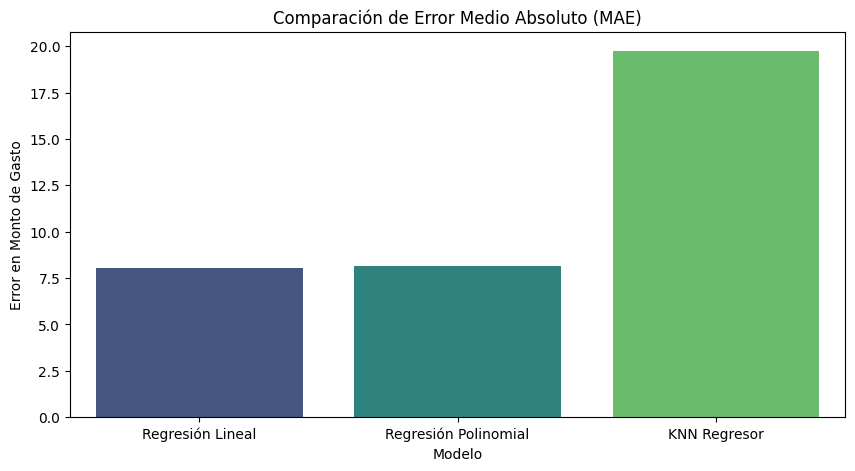

In [ ]:
from sklearn.metrics import mean_squared_error

# 1. Función para obtener todas las métricas de un modelo
def obtener_metricas(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    
    return {'Modelo': nombre_modelo, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# 2. Calcular métricas para los modelos previos
metricas_lineal = obtener_metricas(y_test, y_pred_lineal, "Regresión Lineal")
metricas_poly = obtener_metricas(y_test, y_pred_poly, "Regresión Polinomial")

# Para KNN (Regresor), lo entrenamos rápidamente aquí para comparar
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred_knn = knn_reg.predict(X_test_scaled)
metricas_knn = obtener_metricas(y_test, y_pred_knn, "KNN Regresor")

# 3. Elaborar la Tabla Comparativa
df_metricas = pd.DataFrame([metricas_lineal, metricas_poly, metricas_knn])

print("--- Tabla Comparativa de Desempeño ---")
print(df_metricas.sort_values(by='R2', ascending=False))

# 4. Visualización de errores
plt.figure(figsize=(10, 5))
sns.barplot(x='Modelo', y='MAE', data=df_metricas, palette='viridis')
plt.title('Comparación de Error Medio Absoluto (MAE)')
plt.ylabel('Error en Monto de Gasto')
plt.show()

## Clase 7: Optimización del Modelo

### 1. Ingeniería de Características (Feature Engineering)
Consiste en crear nuevas variables a partir de las existentes que capturen mejor la relación con el objetivo. Por ejemplo, podríamos crear una variable `Ratio_App_Web` que capture la preferencia del usuario por un canal sobre el otro.

### 2. Ajuste de Hiperparámetros (GridSearchCV)
Cada algoritmo tiene "perillas" (hiperparámetros) que controlan su comportamiento. `GridSearchCV` nos permite probar cientos de combinaciones automáticamente y elegir la que minimiza el error, usando validación cruzada para asegurar robustez.

### 3. Regularización (Ridge y Lasso)
Son técnicas que añaden una "penalización" a los coeficientes del modelo. 
* **Ridge (L2):** Reduce la magnitud de los coeficientes, evitando que una variable domine demasiado.
* **Lasso (L1):** Puede reducir coeficientes a cero, lo que ayuda a seleccionar solo las variables más importantes (selección de características).

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso

# 1. Ingeniería de características simple
df['Total_Tiempo'] = df['Tiempo_en_App'] + df['Tiempo_en_Web']
X = df.drop('Gasto_Anual', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Ajuste de Hiperparámetros con GridSearchCV (ejemplo con Ridge)
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train_scaled, y_train)

print(f"Mejor parámetro alpha para Ridge: {grid_ridge.best_params_['alpha']}")

# 3. Comparación de Regularización
modelos_reg = {
    "Ridge": Ridge(alpha=grid_ridge.best_params_['alpha']),
    "Lasso": Lasso(alpha=0.1)
}

for nombre, mod in modelos_reg.items():
    mod.fit(X_train_scaled, y_train)
    y_pred = mod.predict(X_test_scaled)
    print(f"{nombre} R2: {r2_score(y_test, y_pred):.4f}")

Mejor parámetro alpha para Ridge: 0.1
Ridge R2: 0.9944
Lasso R2: 0.9944


## Clase 8: Algoritmos de Boosting (Gradient Boosting)

### 1. ¿Qué es el Enfoque Ensemble?
El Gradient Boosting es un modelo de ensamble que combina múltiples "árboles de decisión" débiles para crear un modelo fuerte. A diferencia de un bosque aleatorio (donde los árboles se entrenan en paralelo), el Boosting lo hace **secuencialmente**: cada árbol nuevo intenta corregir los errores específicos que cometió el árbol anterior.

### 2. Ventajas
* **Alta Precisión:** Suele capturar patrones complejos que modelos lineales no ven.
* **Flexibilidad:** Maneja muy bien relaciones no lineales y datos de diferentes escalas.

### 3. Limitaciones
* **Tiempo de Entrenamiento:** Es más lento que una regresión lineal al entrenar muchos árboles.
* **Riesgo de Sobreajuste:** Si no se controla (ajustando la profundidad de los árboles o el número de estimadores), puede memorizar demasiado bien los datos de entrenamiento.

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Instanciar y entrenar Gradient Boosting (con las 5 variables actuales)
gb_regressor = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_regressor.fit(X_train_scaled, y_train)

# 2. Predecir y evaluar Gradient Boosting
y_pred_gb = gb_regressor.predict(X_test_scaled)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# 3. Re-entrenar un modelo lineal rápido con las 5 variables para que la comparación sea válida
modelo_lineal_final = LinearRegression()
modelo_lineal_final.fit(X_train_scaled, y_train) 
y_pred_lineal_final = modelo_lineal_final.predict(X_test_scaled)
# ---------------------------

print("--- Desempeño: Gradient Boosting ---")
print(f"MAE: {mae_gb:.2f}")
print(f"R²: {r2_gb:.2f}")

print("\n--- Comparación Final ---")
print(f"Modelo Lineal (5 variables) | R²: {r2_score(y_test, y_pred_lineal_final):.2f}")
print(f"Gradient Boosting           | R²: {r2_gb:.2f}")

--- Desempeño: Gradient Boosting ---
MAE: 10.94
R²: 0.99

--- Comparación Final ---
Modelo Lineal (5 variables) | R²: 0.99
Gradient Boosting           | R²: 0.99
